In [1]:
!pip install pandas-datareader

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


Date range: 2015-01-02 → 2024-12-31
Total days: 2612

Min:     2.60%
Max:     10.87%
Mean:    4.34%
Current: 2.92%


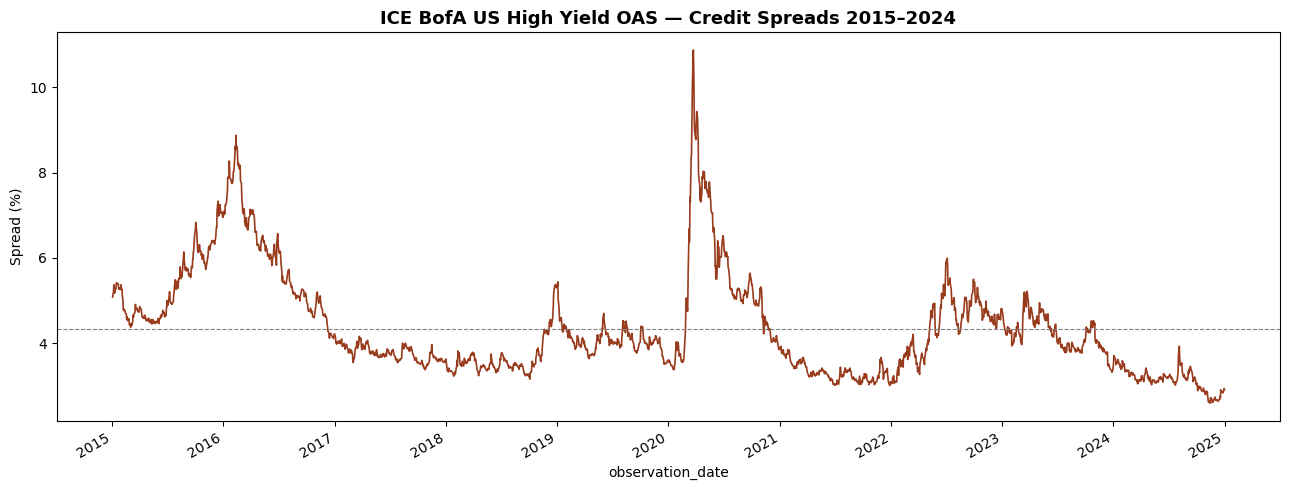


Saved: kroniq_credit_spreads.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load from manually downloaded file
cs = pd.read_csv('fred_graph.csv',
                 index_col=0,
                 parse_dates=True,
                 na_values='.')
cs.columns = ['credit_spread']

# Drop any NaN rows (FRED uses '.' for missing values)
cs = cs.dropna()

# Filter to our research window
cs = cs.loc['2015-01-01':'2024-12-31']

print(f"Date range: {cs.index[0].date()} → {cs.index[-1].date()}")
print(f"Total days: {len(cs)}")
print(f"\nMin:     {cs['credit_spread'].min():.2f}%")
print(f"Max:     {cs['credit_spread'].max():.2f}%")
print(f"Mean:    {cs['credit_spread'].mean():.2f}%")
print(f"Current: {cs['credit_spread'].iloc[-1]:.2f}%")

# Plot
plt.figure(figsize=(13, 5))
cs['credit_spread'].plot(color='#993C1D', linewidth=1.2)
plt.axhline(cs['credit_spread'].mean(), color='gray',
            linestyle='--', linewidth=0.8, label='Mean')
plt.title('ICE BofA US High Yield OAS — Credit Spreads 2015–2024',
          fontsize=13, fontweight='bold')
plt.ylabel('Spread (%)')
plt.tight_layout()
plt.savefig('kroniq_credit_spreads.png', dpi=150)
plt.show()

cs.to_csv('kroniq_credit_spreads.csv')
print("\nSaved: kroniq_credit_spreads.csv")